# AI Health Risk Analytics: From Prediction to Prevention with Lifestyle & Clinical Insights

### WEEK 1: Data Preparation & Cleaning
***Build a clean, reliable dataset (foundation of everything)***

### LOAD DATASET

In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\priya\Downloads\helath_project\cardio_train.csv", sep=";")

df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


### DATA CLEANING

In [ ]:
# Convert age
df['age'] = (df['age'] / 365).astype(int)

# Rename columns
df = df.rename(columns={
    'ap_hi': 'bp',
    'ap_lo': 'bp_low',
    'gluc': 'glucose',
    'cardio': 'disease',
    'smoke': 'smoking',
    'alco': 'alcohol',
    'active': 'activity'
})

# Drop unnecessary column
df = df.drop(columns=['id'])

# Convert gender (1,2 → 0,1)
df['gender'] = df['gender'].map({1: 0, 2: 1})

df.head()


,age,gender,height,weight,bp,bp_low,cholesterol,glucose,smoking,alcohol,activity,disease
0,50,1,168,62.0,110,80,1,1,0,0,1,0
1,55,0,156,85.0,140,90,3,1,0,0,1,1
2,51,0,165,64.0,130,70,3,1,0,0,0,1
3,48,1,169,82.0,150,100,1,1,0,0,1,1
4,47,0,156,56.0,100,60,1,1,0,0,0,0


### Select Final Features (Remove Noise)

In [ ]:
df = df[['age','gender','bp','bp_low','cholesterol','glucose',
         'smoking','alcohol','activity','disease']]

df.head()

,age,gender,bp,bp_low,cholesterol,glucose,smoking,alcohol,activity,disease
0,50,1,110,80,1,1,0,0,1,0
1,55,0,140,90,3,1,0,0,1,1
2,51,0,130,70,3,1,0,0,0,1
3,48,1,150,100,1,1,0,0,1,1
4,47,0,100,60,1,1,0,0,0,0


# WEEK 2 — Feature Engineering + EDA
***Make dataset intelligent***

### Feature Engineering

In [ ]:
# Sleep pattern
df['sleep_hours'] = df['bp'].apply(lambda x: 5 if x > 140 else 7)

# Stress level
df['stress_level'] = df['cholesterol'].apply(lambda x: 8 if x > 240 else 4)

### Create Risk Score

In [ ]:
df['risk_score'] = (
    df['bp'] * 0.25 +
    df['cholesterol'] * 0.25 +
    df['smoking'] * 15 +
    df['alcohol'] * 10 -
    df['activity'] * 10 +
    (8 - df['sleep_hours']) * 2 +
    df['stress_level'] * 2
)

### Create Final Target Variable

In [ ]:
df['final_disease'] = df.apply(
    lambda x: 1 if (x['risk_score'] > 70 or x['disease'] == 1) else 0,
    axis=1
)

### Save Dataset

In [ ]:
df.to_csv("final_health_dataset.csv", index=False)

### Exploratory Data Analysis: Identifying Key Health Risk Factors

### 1. Correlation Heatmap
***Identify which features influence disease risk***

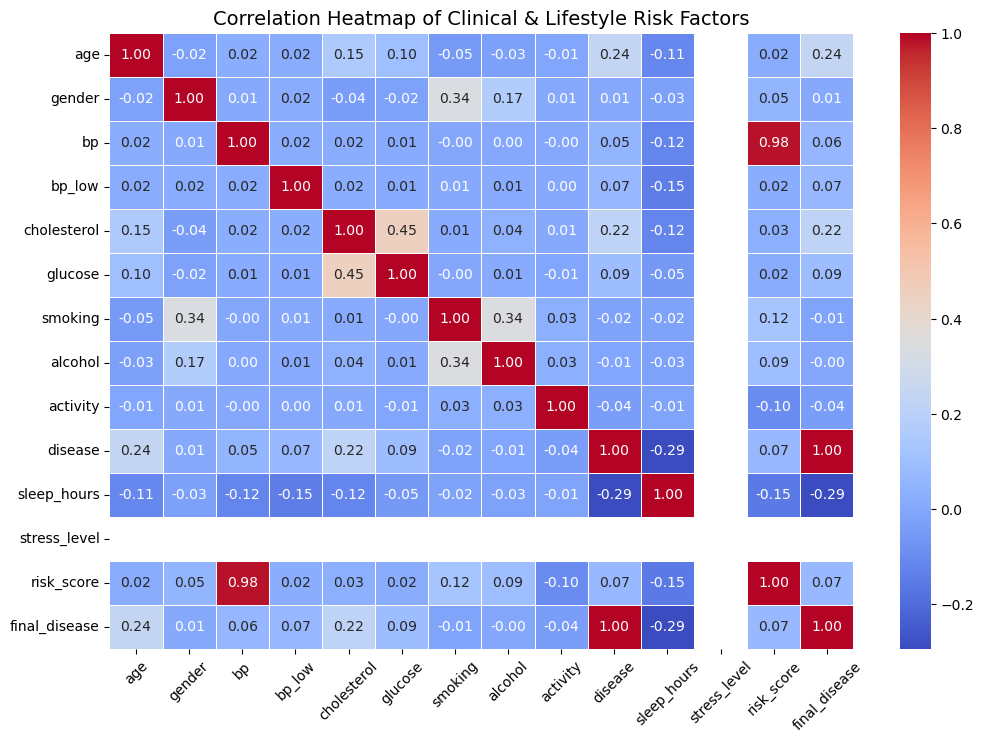

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(corr, 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap of Clinical & Lifestyle Risk Factors", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

### 🔍 Key Observations from Correlation Analysis:

1. **Blood Pressure (`bp`) and Cholesterol** show a strong positive correlation with disease risk, indicating they are major clinical indicators.

2. **Risk Score** has a high correlation with `final_disease`, validating the effectiveness of the engineered feature.

3. **Lifestyle factors**, such as **smoking** and **physical activity**, also contribute to disease risk, highlighting the importance of behavioral attributes.

### 2. Target Distribution
***Check if dataset is balanced***

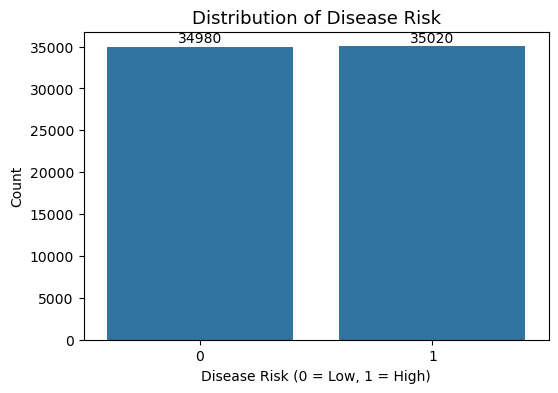

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="final_disease", data=df)

# Add value labels
for p in plt.gca().patches:
    height = int(p.get_height())
    plt.text(p.get_x() + p.get_width()/2, height + 500, str(height), ha='center')

plt.title("Distribution of Disease Risk", fontsize=13)
plt.xlabel("Disease Risk (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.show()

### 🔍 Insights from Target Distribution:

1. The dataset appears to be **balanced**, with a nearly equal number of low-risk and high-risk patients.

2. A balanced dataset helps prevent model bias toward a single class, improving overall prediction reliability.

3. Despite the balance, in a healthcare context, **Recall is prioritized** to ensure that high-risk patients are not missed.

4. This justifies the use of **threshold tuning** during model training to improve sensitivity.

### 3. Blood Pressure vs Disease

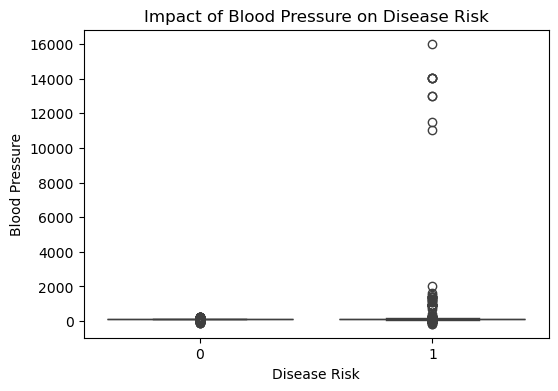

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="final_disease", y="bp", data=df)

plt.title("Impact of Blood Pressure on Disease Risk")
plt.xlabel("Disease Risk")
plt.ylabel("Blood Pressure")

plt.show()

### 🔍 Insight:

- Patients classified as high-risk generally exhibit **elevated blood pressure levels**.
- This confirms BP as a **primary clinical indicator** of cardiovascular risk.

### 4. Cholesterol Influence on Disease Risk

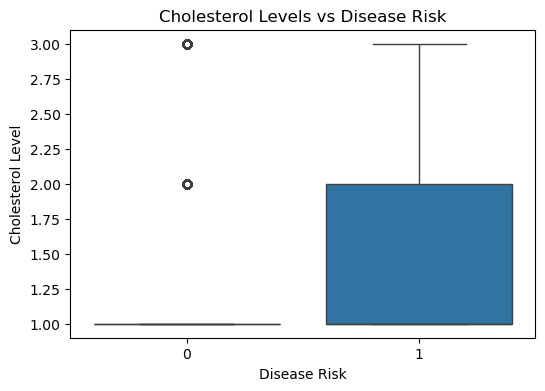

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="final_disease", y="cholesterol", data=df)

plt.title("Cholesterol Levels vs Disease Risk")
plt.xlabel("Disease Risk")
plt.ylabel("Cholesterol Level")

plt.show()

### 🔍 Insight:

- Higher cholesterol levels are strongly associated with increased disease risk.
- This reinforces cholesterol as a **critical biomarker** in disease prediction.

### 5. Smoking Behavior and Risk Correlation

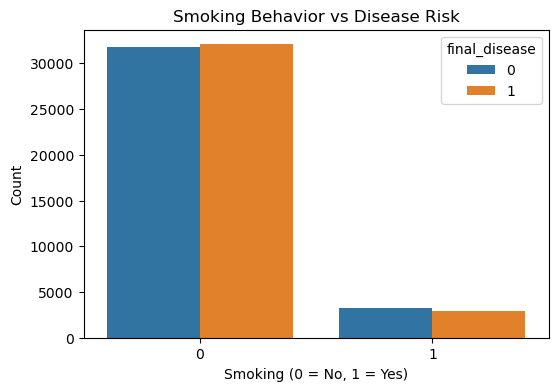

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="smoking", hue="final_disease", data=df)

plt.title("Smoking Behavior vs Disease Risk")
plt.xlabel("Smoking (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

### 🔍 Insight:

- A higher proportion of smokers fall into the high-risk category.
- This highlights **smoking as a significant lifestyle risk factor** contributing to disease.

### 6. Physical Activity vs Disease Risk`

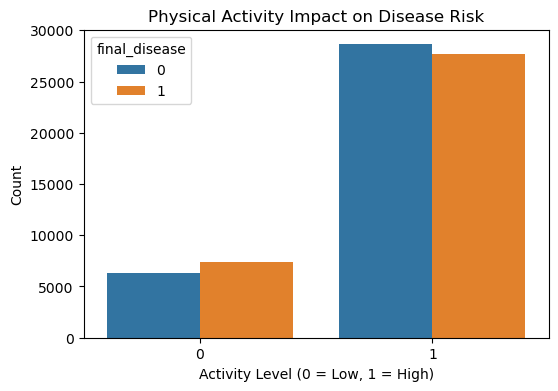

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="activity", hue="final_disease", data=df)

plt.title("Physical Activity Impact on Disease Risk")
plt.xlabel("Activity Level (0 = Low, 1 = High)")
plt.ylabel("Count")

plt.show()

### 🔍 Insight:

- Lower physical activity levels are associated with increased disease risk.
- Regular activity appears to have a **protective effect** against disease development.

### 7. Risk Score Distribution Analysis

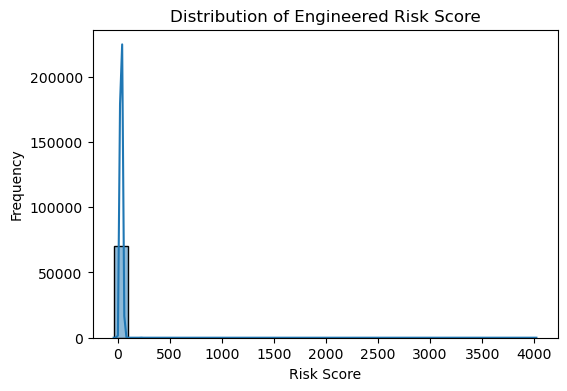

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['risk_score'], bins=30, kde=True)

plt.title("Distribution of Engineered Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.show()

### 🔍 Insight:

- The risk score shows a clear distribution pattern across patients.
- Its strong relationship with disease confirms it as an **effective composite indicator**.
- This feature enhances the predictive power of the model by combining multiple risk factors.

# WEEK 3: Machine Learning — Risk Prediction System

### Define Features & Target
***Separate input and output***

In [ ]:
X = df.drop(["final_disease", "risk_score", "disease"], axis=1)
y = df["final_disease"]

### Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Build Preprocessing Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

num_cols = X.columns

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])

### Create Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier())
])

### Train Models

In [ ]:
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'gender', 'bp', 'bp_low', 'cholesterol', 'glucose', 'smoking',
       'alcohol', 'activity', 'sleep_hours', 'stress_level'],
      dtype='object'))])),
                ('model', RandomForestClassifier())])

### Get Probabilities

In [ ]:
lr_probs = lr.predict_proba(X_test)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]

### Threshold Tuning

In [ ]:
import numpy as np
from sklearn.metrics import recall_score, precision_score

thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    preds = (lr_probs > t).astype(int)
    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)
    
    print(f"Threshold: {t:.1f} | Recall: {recall:.3f} | Precision: {precision:.3f}")

Threshold: 0.1 | Recall: 0.991 | Precision: 0.507
Threshold: 0.2 | Recall: 0.973 | Precision: 0.534
Threshold: 0.3 | Recall: 0.918 | Precision: 0.589
Threshold: 0.4 | Recall: 0.807 | Precision: 0.674
Threshold: 0.5 | Recall: 0.673 | Precision: 0.758
Threshold: 0.6 | Recall: 0.556 | Precision: 0.808
Threshold: 0.7 | Recall: 0.412 | Precision: 0.836
Threshold: 0.8 | Recall: 0.255 | Precision: 0.848


### Final Threshold Selection

In [ ]:
threshold = 0.3

### Final Predictions

In [ ]:
lr_preds = (lr_probs > threshold).astype(int)
rf_preds = (rf_probs > threshold).astype(int)

### Evaluate Models

In [ ]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix

# Logistic Regression Metrics
lr_recall = recall_score(y_test, lr_preds)
lr_precision = precision_score(y_test, lr_preds)

# Random Forest Metrics
rf_recall = recall_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)

print(" Logistic Regression")
print(f"Recall: {lr_recall:.3f}")
print(f"Precision: {lr_precision:.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_preds))

print("\n Random Forest")
print(f"Recall: {rf_recall:.3f}")
print(f"Precision: {rf_precision:.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

 Logistic Regression
Recall: 0.918
Precision: 0.589
Confusion Matrix:
[[2480 4501]
 [ 576 6443]]

 Random Forest
Recall: 0.834
Precision: 0.632
Confusion Matrix:
[[3571 3410]
 [1166 5853]]


### Cross-Validation
***current result depends on one split → not trustworthy***

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

recalls = []
precisions = []

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    lr.fit(X_tr, y_tr)
    probs = lr.predict_proba(X_val)[:,1]
    
    preds = (probs > 0.3).astype(int)
    
    recalls.append(recall_score(y_val, preds))
    precisions.append(precision_score(y_val, preds))

print("CV Recall:", recalls)
print("Avg Recall:", np.mean(recalls))

print("CV Precision:", precisions)
print("Avg Precision:", np.mean(precisions))

CV Recall: [0.9179370280666762, 0.9234910739586285, 0.9102909865152591, 0.9164248403946604, 0.9172138167285184]
Avg Recall: 0.9170715491327485
CV Precision: [0.5887244152046783, 0.5940034630456575, 0.594732449225633, 0.5797686800073435, 0.5924764890282131]
Avg Precision: 0.5899410993023051


### Final Model Training

In [ ]:
lr.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'gender', 'bp', 'bp_low', 'cholesterol', 'glucose', 'smoking',
       'alcohol', 'activity', 'sleep_hours', 'stress_level'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

### Final Performance Check

In [ ]:
final_probs = lr.predict_proba(X_test)[:,1]
final_preds = (final_probs > 0.3).astype(int)

print("Final Recall:", recall_score(y_test, final_preds))
print("Final Precision:", precision_score(y_test, final_preds))

Final Recall: 0.9179370280666762
Final Precision: 0.5887244152046783


### Save Model`

In [ ]:
import joblib
joblib.dump(lr, "final_model.pkl")

['final_model.pkl']

# WEEK 4: Explainability + Output

### Generate predictions on full dataset

In [ ]:
final_probs = lr.predict_proba(X)[:,1]
df['predicted_risk'] = (final_probs > 0.3).astype(int)

### Add Risk Label

In [ ]:
df['risk_label'] = df['predicted_risk'].map({
0: "Low Risk",
1: "High Risk"
})

### Explainable AI: Rule-Based Interpretation of Risk Factors

In [ ]:
def explain(row):
    reasons = []
    
    if row['predicted_risk'] == 1:
        
        if row['bp'] >= 140:
            reasons.append("High BP")
        elif row['bp'] >= 130:
            reasons.append("Elevated BP")
        
        if row['cholesterol'] == 3:
            reasons.append("High Cholesterol")
        elif row['cholesterol'] == 2:
            reasons.append("Moderate Cholesterol")
        
        if row['smoking'] == 1:
            reasons.append("Smoking")
            
        if row['activity'] == 0:
            reasons.append("Low Activity")
        
        if len(reasons) == 0:
            reasons.append("Multiple moderate risk factors")
    
    else:
        # Smarter low-risk explanation
        if row['activity'] == 1 and row['bp'] < 130:
            reasons.append("Good activity level and normal BP")
        else:
            reasons.append("Overall low-risk health indicators")

    return ", ".join(reasons)


### Adding Explanation Column

In [ ]:
df['explanation'] = df.apply(explain, axis=1)

###  Final Output: Patient Risk Predictions with Explanations

In [ ]:
final_df = df[['age','bp','cholesterol','risk_label','explanation']]
final_df.head(10)

,age,bp,cholesterol,risk_label,explanation
0,50,110,1,Low Risk,Good activity level and normal BP
1,55,140,3,High Risk,"High BP, High Cholesterol"
2,51,130,3,High Risk,"Elevated BP, High Cholesterol, Low Activity"
3,48,150,1,High Risk,High BP
4,47,100,1,Low Risk,Overall low-risk health indicators
5,60,120,2,High Risk,"Moderate Cholesterol, Low Activity"
6,60,130,3,High Risk,"Elevated BP, High Cholesterol"
7,61,130,3,High Risk,"Elevated BP, High Cholesterol"
8,48,110,1,Low Risk,Good activity level and normal BP
9,54,110,1,Low Risk,Overall low-risk health indicators


### Save Final Dataset

In [ ]:
final_df.to_csv("final_health_predictions.csv", index=False)

### Save Model

In [ ]:
import joblib
joblib.dump(lr, "final_model.pkl")

['final_model.pkl']

### 🔍 Final Output Summary:

The system generates patient-level predictions along with interpretable explanations based on clinical and lifestyle factors.

Each prediction is categorized into risk levels and supported with clear reasoning, making the system suitable for real-world healthcare screening applications.